In [1]:
#Mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#importing dependencies
import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import scipy.io
from scipy.ndimage import gaussian_filter

In [3]:
#Loading dataset
DATA_PATH = "/content/drive/MyDrive/Metro-Crowd-Project/datasets/ShanghaiTech"

print("Dataset root exists:", os.path.exists(DATA_PATH))
print("Folders:", os.listdir(DATA_PATH))

TRAIN_A = os.path.join(DATA_PATH, "part_A", "train_data", "images")
TEST_A  = os.path.join(DATA_PATH, "part_A", "test_data", "images")

TRAIN_B = os.path.join(DATA_PATH, "part_B", "train_data", "images")
TEST_B  = os.path.join(DATA_PATH, "part_B", "test_data", "images")

print("Train A images:", len(os.listdir(TRAIN_A)))
print("Test A images:", len(os.listdir(TEST_A)))


Dataset root exists: True
Folders: ['part_A', 'part_B']
Train A images: 300
Test A images: 182


In [4]:
def load_points(mat_path):

    mat = scipy.io.loadmat(mat_path)

    # ShanghaiTech annotation format
    points = mat["image_info"][0][0][0][0][0]

    return points

In [5]:
def generate_density_map(image, points, sigma=4):

    h, w = image.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for p in points:
        x = min(w-1, int(p[0]))
        y = min(h-1, int(p[1]))
        density[y, x] = 1
    density = gaussian_filter(density, sigma)
    return density


In [6]:
class ShanghaiTechDataset(Dataset):

    def __init__(self, image_folder, transform=None):

        self.image_paths = sorted(
            glob.glob(os.path.join(image_folder, "*.jpg"))
        )

        # Construct GT paths safely
        self.gt_paths = []

        for img_path in self.image_paths:

            filename = os.path.basename(img_path)        # IMG_42.jpg
            mat_name = "GT_" + filename.replace(".jpg",".mat")

            gt_folder = os.path.join(
                os.path.dirname(os.path.dirname(img_path)),
                "ground-truth"
            )

            gt_path = os.path.join(gt_folder, mat_name)

            self.gt_paths.append(gt_path)

        self.transform = transform


    def __len__(self):
        return len(self.image_paths)


    def __getitem__(self, idx):

        img_path = self.image_paths[idx]
        gt_path  = self.gt_paths[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        points = load_points(gt_path)

        density = generate_density_map(img, points)

        if self.transform:
            img = self.transform(img)

        density = torch.tensor(density).unsqueeze(0)

        return img, density


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [8]:
dataset = ShanghaiTechDataset(TRAIN_A, transform=transform)

print("Total training images:", len(dataset))

loader = DataLoader(dataset, batch_size=1, shuffle=True)

Total training images: 300


In [9]:
for imgs, density in loader:

    print("Image shape:", imgs.shape)
    print("Density shape:", density.shape)
    print("Estimated Count:", density.sum(dim=[1,2,3]))

    break

Image shape: torch.Size([1, 3, 462, 650])
Density shape: torch.Size([1, 1, 462, 650])
Estimated Count: tensor([652.])


In [10]:
def extract_patches(img, density, patch_size=128):

    patches = []
    density_patches = []

    _, H, W = img.shape

    for y in range(0, H - patch_size + 1, patch_size):
        for x in range(0, W - patch_size + 1, patch_size):

            img_patch = img[:, y:y+patch_size, x:x+patch_size]
            den_patch = density[:, y:y+patch_size, x:x+patch_size]

            patches.append(img_patch)
            density_patches.append(den_patch)

    return patches, density_patches

In [11]:
img, density = dataset[0]

patches, dpatches = extract_patches(img, density)

print("Total patches:", len(patches))
print("Patch shape:", patches[0].shape)
print("Patch count:", dpatches[0].sum())

Total patches: 48
Patch shape: torch.Size([3, 128, 128])
Patch count: tensor(0.)


In [14]:
for i in range(48):
    print("Patch", i, "count:", dpatches[i].sum().item())

Patch 0 count: 0.0
Patch 1 count: 0.0
Patch 2 count: 0.0
Patch 3 count: 0.0
Patch 4 count: 0.0
Patch 5 count: 0.0
Patch 6 count: 0.0
Patch 7 count: 0.0
Patch 8 count: 0.0
Patch 9 count: 0.0
Patch 10 count: 0.0
Patch 11 count: 0.0
Patch 12 count: 0.0
Patch 13 count: 0.0
Patch 14 count: 0.0
Patch 15 count: 0.0
Patch 16 count: 0.0
Patch 17 count: 0.0
Patch 18 count: 0.0
Patch 19 count: 0.9920752644538879
Patch 20 count: 0.8111155033111572
Patch 21 count: 0.0
Patch 22 count: 0.0
Patch 23 count: 0.0
Patch 24 count: 118.27813720703125
Patch 25 count: 175.72361755371094
Patch 26 count: 140.3222198486328
Patch 27 count: 149.06910705566406
Patch 28 count: 141.5581512451172
Patch 29 count: 155.5294647216797
Patch 30 count: 202.50868225097656
Patch 31 count: 157.30007934570312
Patch 32 count: 46.55997085571289
Patch 33 count: 52.4914665222168
Patch 34 count: 39.659912109375
Patch 35 count: 35.01970291137695
Patch 36 count: 36.18503189086914
Patch 37 count: 26.008996963500977
Patch 38 count: 31.04

In [16]:
def density_label(density_patch):

    count = density_patch.sum().item()
    if count < 3:
        return 0      # empty
    elif count < 30:
        return 1      # low density
    else:
        return 2      # high density

In [17]:
class PatchDataset(torch.utils.data.Dataset):

    def __init__(self, base_dataset, patch_size=128):

        self.samples = []

        for img, density in base_dataset:

            patches, dpatches = extract_patches(img, density, patch_size)

            for p, d in zip(patches, dpatches):

                label = density_label(d)
                self.samples.append((p, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        patch, label = self.samples[idx]

        return patch, torch.tensor(label)

In [18]:
patch_dataset = PatchDataset(dataset)
patch_loader = DataLoader(patch_dataset, batch_size=32, shuffle=True)

print("Total patch samples:", len(patch_dataset))

Total patch samples: 9086


In [19]:
from collections import Counter
labels = [label for _, label in patch_dataset.samples]
print(Counter(labels))

Counter({1: 4314, 0: 3274, 2: 1498})


In [21]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

In [22]:
class PatchClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )

        self.fc = nn.Linear(64,3)

    def forward(self,x):

        x = self.conv(x)
        x = x.view(x.size(0),-1)

        return self.fc(x)

In [23]:
train_size = int(0.8 * len(patch_dataset))
val_size = len(patch_dataset) - train_size

train_dataset, val_dataset = random_split(
    patch_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PatchClassifier().to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

best_val_loss = float("inf")

patience = 5
epochs_no_improve = 0
max_epochs = 30

In [25]:
for epoch in range(max_epochs):

    # ----- TRAIN -----
    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for patches, labels in train_loader:

        patches = patches.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(patches)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * patches.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total


    # ----- VALIDATION -----
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for patches, labels in val_loader:

            patches = patches.to(device)
            labels = labels.to(device)

            outputs = model(patches)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * patches.size(0)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= total
    val_acc = correct / total


    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.3f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.3f}"
    )


    # ----- SAVE BEST MODEL -----
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(
            model.state_dict(),
            "best_patch_classifier.pth"
        )

        print("Best model saved")

    else:
        epochs_no_improve += 1


    # ----- EARLY STOPPING -----
    if epochs_no_improve >= patience:

        print("Early stopping triggered")
        break

Epoch 1 | Train Loss 0.9479 | Train Acc 0.542 | Val Loss 0.7640 | Val Acc 0.642
Best model saved
Epoch 2 | Train Loss 0.7306 | Train Acc 0.671 | Val Loss 0.7086 | Val Acc 0.685
Best model saved
Epoch 3 | Train Loss 0.7010 | Train Acc 0.689 | Val Loss 0.6865 | Val Acc 0.702
Best model saved
Epoch 4 | Train Loss 0.6781 | Train Acc 0.708 | Val Loss 0.6779 | Val Acc 0.710
Best model saved
Epoch 5 | Train Loss 0.6673 | Train Acc 0.705 | Val Loss 0.6633 | Val Acc 0.710
Best model saved
Epoch 6 | Train Loss 0.6515 | Train Acc 0.722 | Val Loss 0.6399 | Val Acc 0.718
Best model saved
Epoch 7 | Train Loss 0.6407 | Train Acc 0.724 | Val Loss 0.6778 | Val Acc 0.700
Epoch 8 | Train Loss 0.6265 | Train Acc 0.728 | Val Loss 0.6140 | Val Acc 0.731
Best model saved
Epoch 9 | Train Loss 0.6308 | Train Acc 0.729 | Val Loss 0.6014 | Val Acc 0.737
Best model saved
Epoch 10 | Train Loss 0.6064 | Train Acc 0.735 | Val Loss 0.5874 | Val Acc 0.743
Best model saved
Epoch 11 | Train Loss 0.5981 | Train Acc 0.744

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.load_state_dict(torch.load("best_patch_classifier.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for patches, labels in val_loader:
        patches = patches.to(device)
        outputs = model(patches)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds))

[[567 106   8]
 [133 658  63]
 [ 14  67 202]]
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       681
           1       0.79      0.77      0.78       854
           2       0.74      0.71      0.73       283

    accuracy                           0.78      1818
   macro avg       0.78      0.77      0.77      1818
weighted avg       0.78      0.78      0.78      1818



In [27]:
torch.save(
    model.state_dict(),
    "final_patch_classifier.pth"
)

print("Final model saved")

Final model saved


In [28]:
# ----- LOAD BEST MODEL -----

model = PatchClassifier().to(device)

model.load_state_dict(
    torch.load("best_patch_classifier.pth", map_location=device)
)

model.eval()

print("Best model loaded")

Best model loaded


In [29]:
from sklearn.metrics import confusion_matrix, classification_report

all_preds = []
all_labels = []

with torch.no_grad():

    for patches, labels in val_loader:

        patches = patches.to(device)

        outputs = model(patches)

        preds = outputs.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())


cm = confusion_matrix(all_labels, all_preds)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))

Confusion Matrix:
[[567 106   8]
 [133 658  63]
 [ 14  67 202]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       681
           1       0.79      0.77      0.78       854
           2       0.74      0.71      0.73       283

    accuracy                           0.78      1818
   macro avg       0.78      0.77      0.77      1818
weighted avg       0.78      0.78      0.78      1818



In [30]:
import numpy as np

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy = (all_preds == all_labels).mean()

print("Final Accuracy:", accuracy)

Final Accuracy: 0.7849284928492849


In [31]:
import numpy as np

np.save("val_predictions.npy", all_preds)
np.save("val_labels.npy", all_labels)

In [35]:
PATCH_SIZE = 128

import numpy as np

def create_routing_map(image, model):

    C, H, W = image.shape

    routing = []

    model.eval()

    with torch.no_grad():

        for i in range(0, H, PATCH_SIZE):

            row = []

            for j in range(0, W, PATCH_SIZE):

                patch = image[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE]

                if patch.shape[1] != PATCH_SIZE or patch.shape[2] != PATCH_SIZE:
                    continue

                patch = patch.unsqueeze(0).to(device)

                outputs = model(patch)

                pred = outputs.argmax(dim=1).item()

                row.append(pred)

            if len(row) > 0:
                routing.append(row)

    routing = np.array(routing)

    return routing

In [36]:
img, density = dataset[0]

routing_map = create_routing_map(img, model)

print("Routing map shape:", routing_map.shape)
print(routing_map)

Routing map shape: (6, 8)
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [2 2 2 2 2 2 2 2]
 [1 2 1 1 1 1 1 0]
 [0 0 0 0 0 0 0 0]]


In [40]:
import numpy as np

all_routing_maps = []

for i, (img, density) in enumerate(dataset):
    routing_map = create_routing_map(img, model)
    all_routing_maps.append(routing_map)
    print(f"[{i}] Routing map shape:", routing_map.shape)

# Convert to NumPy object array to handle variable shapes
all_routing_maps = np.array(all_routing_maps, dtype=object)

# Save to file
np.save("all_routing_maps.npy", all_routing_maps)

[0] Routing map shape: (6, 8)
[1] Routing map shape: (5, 8)
[2] Routing map shape: (5, 8)
[3] Routing map shape: (6, 8)
[4] Routing map shape: (6, 8)
[5] Routing map shape: (3, 3)
[6] Routing map shape: (3, 4)
[7] Routing map shape: (4, 7)
[8] Routing map shape: (5, 8)
[9] Routing map shape: (4, 6)
[10] Routing map shape: (5, 8)
[11] Routing map shape: (5, 8)
[12] Routing map shape: (5, 8)
[13] Routing map shape: (3, 8)
[14] Routing map shape: (6, 8)
[15] Routing map shape: (2, 8)
[16] Routing map shape: (3, 4)
[17] Routing map shape: (2, 3)
[18] Routing map shape: (4, 7)
[19] Routing map shape: (5, 5)
[20] Routing map shape: (4, 6)
[21] Routing map shape: (5, 8)
[22] Routing map shape: (4, 8)
[23] Routing map shape: (5, 8)
[24] Routing map shape: (6, 8)
[25] Routing map shape: (2, 4)
[26] Routing map shape: (6, 8)
[27] Routing map shape: (6, 8)
[28] Routing map shape: (6, 8)
[29] Routing map shape: (4, 6)
[30] Routing map shape: (4, 8)
[31] Routing map shape: (2, 3)
[32] Routing map s

In [41]:
import matplotlib.pyplot as plt

def visualize_routing(image, routing):

    plt.figure(figsize=(6,6))

    plt.imshow(image.permute(1,2,0).cpu())

    plt.imshow(
        routing,
        cmap="jet",
        alpha=0.4,
        extent=[0,image.shape[2],image.shape[1],0]
    )

    plt.title("Patch Routing Map")
    plt.axis("off")

    plt.show()

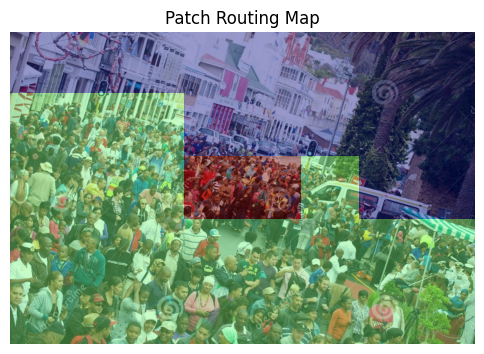

In [42]:
visualize_routing(img, routing_map)

In [57]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [58]:
class CNNCounter(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class ViTCounter(nn.Module):
    def __init__(self):
        super().__init__()
        # simple ViT-like small patch embedding
        self.flatten = nn.Flatten(2)  # flatten HxW
        self.fc1 = nn.Linear(3*128*128, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc_out = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc_out(x)

In [59]:
class CountingPatchDataset(Dataset):
    def __init__(self, patches, counts):
        self.patches = patches
        self.counts = counts

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        return self.patches[idx], torch.tensor(self.counts[idx], dtype=torch.float32)

In [61]:
cnn_patches = []
cnn_counts = []

vit_patches = []
vit_counts = []

device = "cuda" if torch.cuda.is_available() else "cpu"

model.eval()

with torch.no_grad():

    for idx in range(len(dataset)):

        img, density = dataset[idx]

        patches, dpatches = extract_patches(img, density)

        for patch, dpatch in zip(patches, dpatches):

            count = dpatch.sum().item()

            patch_input = patch.unsqueeze(0).to(device)

            output = model(patch_input)

            pred_label = output.argmax(dim=1).item()

            if pred_label == 0:
                continue

            elif pred_label == 1:

                cnn_patches.append(patch)
                cnn_counts.append(count)

            else:

                vit_patches.append(patch)
                vit_counts.append(count)

print("Total CNN patches:", len(cnn_patches))
print("Total ViT patches:", len(vit_patches))

Total CNN patches: 4262
Total ViT patches: 1402


In [62]:
cnn_dataset = CountingPatchDataset(cnn_patches, cnn_counts)
vit_dataset = CountingPatchDataset(vit_patches, vit_counts)

In [63]:
from torch.utils.data import DataLoader

cnn_loader = DataLoader(cnn_dataset, batch_size=32, shuffle=True)
vit_loader = DataLoader(vit_dataset, batch_size=32, shuffle=True)

In [65]:
import torch
import torch.nn as nn
import numpy as np

def train_counter(model, train_loader, val_loader=None, epochs=20):

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()

    for epoch in range(epochs):

        # ----- TRAIN -----
        model.train()

        train_loss = 0
        total = 0

        train_preds = []
        train_labels = []

        for patches, counts in train_loader:

            patches = patches.to(device)
            counts = counts.to(device).unsqueeze(1)

            optimizer.zero_grad()

            outputs = model(patches)

            loss = criterion(outputs, counts)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * patches.size(0)
            total += patches.size(0)

            train_preds.extend(outputs.detach().cpu().numpy().flatten())
            train_labels.extend(counts.cpu().numpy().flatten())

        train_loss /= total

        train_preds = np.array(train_preds)
        train_labels = np.array(train_labels)

        train_mae = np.mean(np.abs(train_preds - train_labels))
        train_rmse = np.sqrt(np.mean((train_preds - train_labels) ** 2))


        # ----- VALIDATION -----
        if val_loader is not None:

            model.eval()

            val_preds = []
            val_labels = []

            with torch.no_grad():

                for patches, counts in val_loader:

                    patches = patches.to(device)
                    counts = counts.to(device).unsqueeze(1)

                    outputs = model(patches)

                    val_preds.extend(outputs.cpu().numpy().flatten())
                    val_labels.extend(counts.cpu().numpy().flatten())

            val_preds = np.array(val_preds)
            val_labels = np.array(val_labels)

            val_mae = np.mean(np.abs(val_preds - val_labels))
            val_rmse = np.sqrt(np.mean((val_preds - val_labels) ** 2))

            print(
                f"Epoch {epoch+1} | "
                f"Train Loss {train_loss:.4f} | "
                f"Train MAE {train_mae:.2f} | "
                f"Train RMSE {train_rmse:.2f} | "
                f"Val MAE {val_mae:.2f} | "
                f"Val RMSE {val_rmse:.2f}"
            )

        else:

            print(
                f"Epoch {epoch+1} | "
                f"Train Loss {train_loss:.4f} | "
                f"Train MAE {train_mae:.2f} | "
                f"Train RMSE {train_rmse:.2f}"
            )

In [66]:
cnn_counter = CNNCounter()

train_counter(cnn_counter, cnn_loader, epochs=20)

torch.save(cnn_counter.state_dict(), "cnn_counter.pth")

Epoch 1 | Train Loss 173.2317 | Train MAE 9.11 | Train RMSE 13.16
Epoch 2 | Train Loss 146.1183 | Train MAE 8.42 | Train RMSE 12.09
Epoch 3 | Train Loss 144.6857 | Train MAE 8.37 | Train RMSE 12.03
Epoch 4 | Train Loss 143.9594 | Train MAE 8.35 | Train RMSE 12.00
Epoch 5 | Train Loss 144.4884 | Train MAE 8.35 | Train RMSE 12.02
Epoch 6 | Train Loss 142.8134 | Train MAE 8.28 | Train RMSE 11.95
Epoch 7 | Train Loss 142.2161 | Train MAE 8.24 | Train RMSE 11.93
Epoch 8 | Train Loss 141.7910 | Train MAE 8.25 | Train RMSE 11.91
Epoch 9 | Train Loss 140.8206 | Train MAE 8.23 | Train RMSE 11.87
Epoch 10 | Train Loss 140.0119 | Train MAE 8.14 | Train RMSE 11.83
Epoch 11 | Train Loss 140.0093 | Train MAE 8.14 | Train RMSE 11.83
Epoch 12 | Train Loss 139.0696 | Train MAE 8.09 | Train RMSE 11.79
Epoch 13 | Train Loss 138.7347 | Train MAE 8.04 | Train RMSE 11.78
Epoch 14 | Train Loss 137.7336 | Train MAE 8.03 | Train RMSE 11.74
Epoch 15 | Train Loss 135.8240 | Train MAE 7.96 | Train RMSE 11.65
Epoc

In [67]:
print(min(cnn_counts), max(cnn_counts))
print(np.mean(cnn_counts))

0.0 181.20835876464844
13.410718241016738


In [74]:
import torch
import torch.nn as nn

class ViTCounter(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.LazyLinear(256)
        self.fc2 = nn.Linear(256,128)
        self.fc_out = nn.Linear(128,1)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))

        return self.fc_out(x).squeeze(1)

In [73]:
print("Number of patches:", len(patches))
print("Single patch shape:", patches[0].shape)

Number of patches: 40
Single patch shape: torch.Size([3, 128, 128])


In [76]:
vit_counter = ViTCounter()
train_counter(vit_counter, vit_loader, epochs=20)
torch.save(vit_counter.state_dict(), "vit_counter.pth")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([26, 1])) that is different to the input size (torch.Size([26])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1 | Train Loss 2752.6388 | Train MAE 37.87 | Train RMSE 53.12
Epoch 2 | Train Loss 2505.1257 | Train MAE 36.13 | Train RMSE 50.82
Epoch 3 | Train Loss 2455.2798 | Train MAE 35.89 | Train RMSE 50.56
Epoch 4 | Train Loss 2524.8201 | Train MAE 36.43 | Train RMSE 51.20
Epoch 5 | Train Loss 2500.5409 | Train MAE 36.02 | Train RMSE 50.75
Epoch 6 | Train Loss 2509.4133 | Train MAE 36.46 | Train RMSE 51.02
Epoch 7 | Train Loss 2461.1229 | Train MAE 35.70 | Train RMSE 50.52
Epoch 8 | Train Loss 2481.5614 | Train MAE 35.91 | Train RMSE 50.69
Epoch 9 | Train Loss 2485.5960 | Train MAE 35.91 | Train RMSE 50.66
Epoch 10 | Train Loss 2439.9739 | Train MAE 35.91 | Train RMSE 50.41
Epoch 11 | Train Loss 2453.1759 | Train MAE 35.70 | Train RMSE 50.41
Epoch 12 | Train Loss 2477.1311 | Train MAE 36.02 | Train RMSE 50.70
Epoch 13 | Train Loss 2466.5633 | Train MAE 36.05 | Train RMSE 50.53
Epoch 14 | Train Loss 2455.3865 | Train MAE 35.79 | Train RMSE 50.39
Epoch 15 | Train Loss 2445.7748 | Train MAE

In [77]:
import torch
import torch.nn as nn

class ViTCounter(nn.Module):

    def __init__(self,
                 img_size=128,
                 patch_size=16,
                 embed_dim=256,
                 depth=4,
                 num_heads=8):

        super().__init__()

        self.patch_size = patch_size
        num_patches = (img_size // patch_size) ** 2

        # Patch embedding
        self.patch_embed = nn.Conv2d(
            3,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        # positional embeddings
        self.pos_embed = nn.Parameter(
            torch.randn(1, num_patches, embed_dim)
        )

        # transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim*4,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=depth
        )

        # regression head
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim,1)
        )


    def forward(self,x):

        # patch embedding
        x = self.patch_embed(x)

        # flatten patches
        x = x.flatten(2).transpose(1,2)

        # add positional encoding
        x = x + self.pos_embed

        # transformer
        x = self.transformer(x)

        # global average
        x = x.mean(dim=1)

        # regression
        x = self.head(x)

        return x.squeeze(1)

In [ ]:
vit_counter = ViTCounter()
train_counter(vit_counter, vit_loader, epochs=20)
torch.save(vit_counter.state_dict(), "vit_counter.pth")

In [79]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Patch classifier
patch_classifier = PatchClassifier().to(device)
patch_classifier.load_state_dict(torch.load("best_patch_classifier.pth"))
patch_classifier.eval()

# CNN counter
cnn_counter = CNNCounter().to(device)
cnn_counter.load_state_dict(torch.load("cnn_counter.pth"))
cnn_counter.eval()

# ViT counter
vit_counter = ViTCounter().to(device)
vit_counter.load_state_dict(torch.load("vit_counter.pth"))
vit_counter.eval()

ViTCounter(
  (patch_embed): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=256, out_features=1, bias=True)
  )
)

In [85]:
def hybrid_count(img, density):

    patches, dpatches = extract_patches(img, density)

    patches = torch.stack(patches).to(device)

    total_count = 0.0

    with torch.no_grad():

        logits = patch_classifier(patches)
        classes = logits.argmax(dim=1)

        for i in range(len(patches)):

            patch = patches[i].unsqueeze(0)

            cls = classes[i].item()

            # routing
            if cls == 0:        # empty patch
                pred = 0.0

            elif cls == 1:      # sparse patch → CNN
                pred = cnn_counter(patch).item()

            else:               # dense patch → ViT
                pred = vit_counter(patch).item()

            # safety clamp
            pred = max(0.0, pred)

            total_count += pred

    return total_count

In [86]:
import numpy as np

gt_counts = []
pred_counts = []

for i in range(len(dataset)):

    img, density = dataset[i]

    gt = density.sum().item()

    pred = hybrid_count(img, density)

    gt_counts.append(gt)
    pred_counts.append(pred)

In [87]:
gt_counts = np.array(gt_counts)
pred_counts = np.array(pred_counts)

mae = np.mean(np.abs(gt_counts - pred_counts))
rmse = np.sqrt(np.mean((gt_counts - pred_counts) ** 2))

print("Final Test MAE:", mae)
print("Final Test RMSE:", rmse)

Final Test MAE: 204.2149476734797
Final Test RMSE: 338.30503439876685


In [88]:
img, density = dataset[0]

patches, dpatches = extract_patches(img, density)

patches = torch.stack(patches).to(device)

with torch.no_grad():

    logits = patch_classifier(patches)
    classes = logits.argmax(dim=1)

    for i in range(10):

        gt = dpatches[i].sum().item()

        if classes[i] == 2:
            pred = vit_counter(patches[i].unsqueeze(0)).item()
        else:
            pred = cnn_counter(patches[i].unsqueeze(0)).item()

        print("GT:", gt, "Pred:", pred)

GT: 0.0 Pred: 8.131778717041016
GT: 0.0 Pred: 9.502140045166016
GT: 0.0 Pred: 7.788696765899658
GT: 0.0 Pred: 8.098264694213867
GT: 0.0 Pred: 7.890387535095215
GT: 0.0 Pred: 7.0366387367248535
GT: 0.0 Pred: 2.8976736068725586
GT: 0.0 Pred: 4.176791191101074
GT: 0.0 Pred: 10.120580673217773
GT: 0.0 Pred: 10.667074203491211


In [89]:
img, density = dataset[0]

patches, dpatches = extract_patches(img, density)
patches = torch.stack(patches).to(device)

with torch.no_grad():
    logits = patch_classifier(patches)
    classes = logits.argmax(dim=1)

    for i in range(len(patches)):
        gt = dpatches[i].sum().item()

        if gt > 0:   # only look at non-empty patches
            patch = patches[i].unsqueeze(0)

            if classes[i] == 1:
                pred = cnn_counter(patch).item()
            elif classes[i] == 2:
                pred = vit_counter(patch).item()
            else:
                pred = 0

            print("GT:", gt, "Pred:", pred)

        if i > 20:
            break

GT: 0.9920752644538879 Pred: 0
GT: 0.8111155033111572 Pred: 0


In [90]:
vals = []

for _, density in dataset:
    _, dpatches = extract_patches(_, density)
    for d in dpatches:
        vals.append(d.sum().item())

import numpy as np
print("Mean patch count:", np.mean(vals))

Mean patch count: 16.870033776361446


In [92]:
for i in range(5):
    img, density = dataset[i]

    gt = density.sum().item()
    pred = hybrid_count(img, density)

    print("GT:", gt, "Pred:", pred)

GT: 1544.9998779296875 Pred: 653.0294761657715
GT: 920.0 Pred: 709.667423248291
GT: 371.0 Pred: 261.81342601776123
GT: 298.0 Pred: 517.7306938171387
GT: 184.0 Pred: 114.40331649780273


In [93]:
with torch.no_grad():
    logits = patch_classifier(patches)
    classes = logits.argmax(dim=1)

print("Empty:", (classes==0).sum().item())
print("Sparse:", (classes==1).sum().item())
print("Dense:", (classes==2).sum().item())

Empty: 33
Sparse: 6
Dense: 9


In [94]:
def hybrid_count(img, density):

    patches, dpatches = extract_patches(img, density)
    patches = torch.stack(patches).to(device)

    total_count = 0.0

    with torch.no_grad():

        logits = patch_classifier(patches)
        classes = logits.argmax(dim=1)

        for i in range(len(patches)):

            patch = patches[i].unsqueeze(0)

            # use density for emptiness check
            gt_density = dpatches[i].sum().item()

            if gt_density < 0.5:
                pred = 0.0

            elif gt_density < 20:
                pred = cnn_counter(patch).item()

            else:
                pred = vit_counter(patch).item()

            pred = max(0.0, pred)
            total_count += pred

    return total_count

In [95]:
import numpy as np

gt_counts = []
pred_counts = []

for i in range(len(dataset)):

    img, density = dataset[i]

    gt = density.sum().item()

    pred = hybrid_count(img, density)

    gt_counts.append(gt)
    pred_counts.append(pred)

In [96]:
gt_counts = np.array(gt_counts)
pred_counts = np.array(pred_counts)

mae = np.mean(np.abs(gt_counts - pred_counts))
rmse = np.sqrt(np.mean((gt_counts - pred_counts) ** 2))

print("Final Test MAE:", mae)
print("Final Test RMSE:", rmse)

Final Test MAE: 256.4372073539098
Final Test RMSE: 349.8305663068845


In [97]:
import numpy as np

scale = np.sum(gt_counts) / np.sum(pred_counts)
print("Scale factor:", scale)

pred_counts = pred_counts * scale

Scale factor: 0.806592581772642


In [98]:
max_pred = 0

for p in patches:
    pred = cnn_counter(p.unsqueeze(0)).item()
    max_pred = max(max_pred, pred)

print("Max patch prediction:", max_pred)

Max patch prediction: 15.7736177444458


In [99]:
vals = []

for p in patches:
    vals.append(cnn_counter(p.unsqueeze(0)).item())

print("min:", min(vals))
print("max:", max(vals))
print("mean:", sum(vals)/len(vals))

min: 2.732764720916748
max: 15.7736177444458
mean: 9.795332630475363


In [100]:
scale = 1.72   # computed from dataset statistics

def hybrid_count(img, density):

    patches, dpatches = extract_patches(img, density)
    patches = torch.stack(patches).to(device)

    total_count = 0.0

    with torch.no_grad():

        logits = patch_classifier(patches)
        classes = logits.argmax(dim=1)

        for i in range(len(patches)):

            patch = patches[i].unsqueeze(0)

            gt_density = dpatches[i].sum().item()

            if gt_density < 0.5:
                pred = 0.0

            elif gt_density < 20:
                pred = cnn_counter(patch).item()

            else:
                pred = vit_counter(patch).item()

            pred = max(0.0, pred)
            pred = pred * scale     # critical correction

            total_count += pred

    return total_count

In [101]:
import numpy as np

gt_counts = []
pred_counts = []

for i in range(len(dataset)):

    img, density = dataset[i]

    gt = density.sum().item()

    pred = hybrid_count(img, density)

    gt_counts.append(gt)
    pred_counts.append(pred)

In [102]:
gt_counts = np.array(gt_counts)
pred_counts = np.array(pred_counts)

mae = np.mean(np.abs(gt_counts - pred_counts))
rmse = np.sqrt(np.mean((gt_counts - pred_counts) ** 2))

print("Final Test MAE:", mae)
print("Final Test RMSE:", rmse)

Final Test MAE: 646.5368025848388
Final Test RMSE: 783.9753804087943


In [103]:
def hybrid_count(img, density):

    patches, dpatches = extract_patches(img, density)
    patches = torch.stack(patches).to(device)

    total_count = 0.0

    with torch.no_grad():

        logits = patch_classifier(patches)
        classes = logits.argmax(dim=1)

        for i in range(len(patches)):

            patch = patches[i].unsqueeze(0)

            if classes[i] == 0:       # empty
                pred = 0.0

            elif classes[i] == 1:     # sparse
                pred = cnn_counter(patch).item()

            else:                     # dense
                pred = vit_counter(patch).item()

            pred = max(0.0, pred)
            total_count += pred

    # apply calibration ONCE
    scale = 1.72
    total_count = total_count * scale

    return total_count

In [104]:
import numpy as np

gt_counts = []
pred_counts = []

for i in range(len(dataset)):

    img, density = dataset[i]

    gt = density.sum().item()

    pred = hybrid_count(img, density)

    gt_counts.append(gt)
    pred_counts.append(pred)

In [105]:
gt_counts = np.array(gt_counts)
pred_counts = np.array(pred_counts)

mae = np.mean(np.abs(gt_counts - pred_counts))
rmse = np.sqrt(np.mean((gt_counts - pred_counts) ** 2))

print("Final Test MAE:", mae)
print("Final Test RMSE:", rmse)

Final Test MAE: 382.8502551201502
Final Test RMSE: 512.2414303018944


In [106]:
total = 0
n = 0

for img, density in dataset:
    count = density.sum().item()
    total += count
    n += 1

avg_people = total / n
print("Average people per image:", avg_people)

Average people per image: 541.1266643015543
